I want to compute statistical significance of context_variants for BC detection. But just trying to show with venn-diagram representation.

In [3]:
!pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45389 sha256=476901c4775f221e4e9d0e8ee62542e1b6a51b2adab9b9cb6a4dfb5659114951
  Stored in directory: /Users/rachnaraj/Library/Caches/pip/wheels/c4/16/4a/93374cd955bbe0553a8ce74db7f0fbd5fcc876e19fb78bd601
Successfully built matplotlib-venn



GPT-4o:
  Minimal only        : 2
  Method only         : 0
  Class only          : 9
  Minimal & Method    : 0
  Minimal & Class     : 5
  Method  & Class     : 3
  All three           : 10
  None                : 60
  Total BUMP          : 89

Qwen-480B:
  Minimal only        : 3
  Method only         : 4
  Class only          : 4
  Minimal & Method    : 1
  Minimal & Class     : 1
  Method  & Class     : 2
  All three           : 13
  None                : 61
  Total BUMP          : 89

GPT-OSS-120b:
  Minimal only        : 1
  Method only         : 0
  Class only          : 2
  Minimal & Method    : 0
  Minimal & Class     : 0
  Method  & Class     : 5
  All three           : 3
  None                : 78
  Total BUMP          : 89


/Users/rachnaraj/miniforge/envs/dev/lib/python3.11/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")



Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.pdf
Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.png


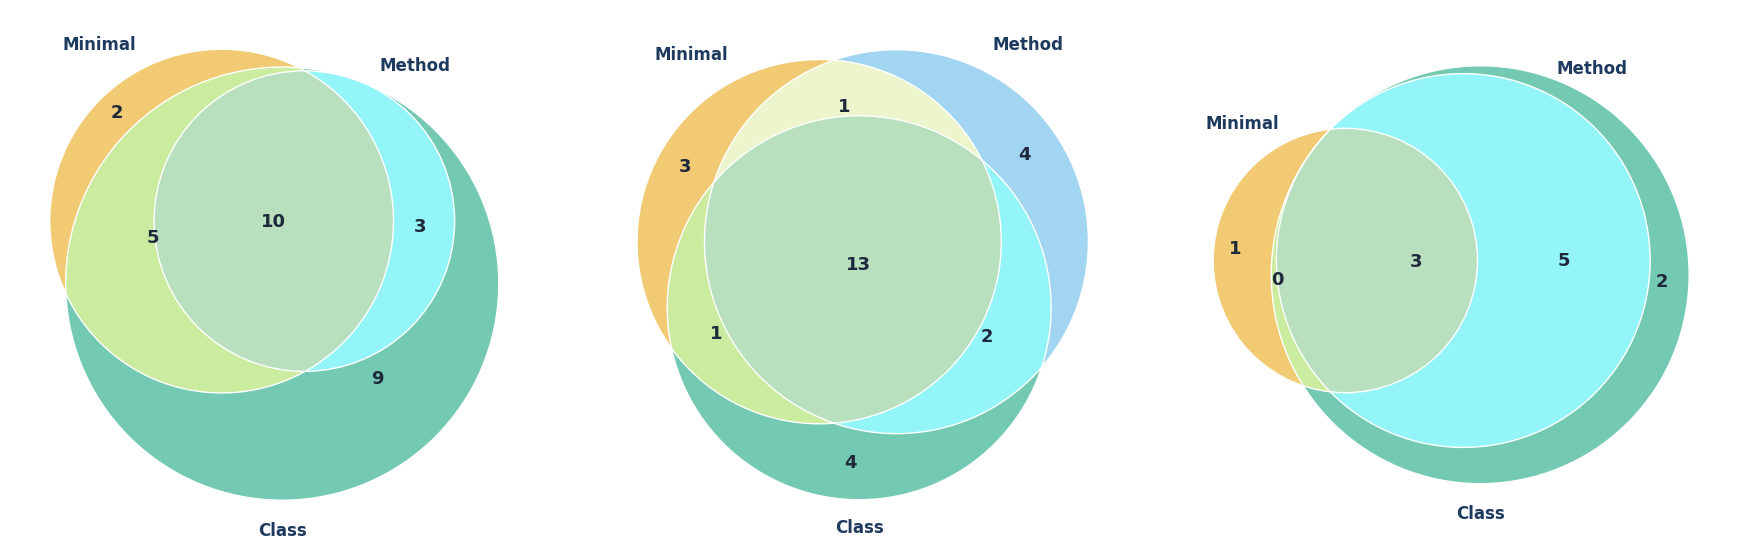

In [ ]:
"""
Install first (run once in your notebook):
  !pip install matplotlib-venn

venn_context_detection.py
==========================
Generates one 3-way Venn diagram per model showing which instances
are detected by Minimal, Method, and/or Class context variants.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_venn import venn3, venn3_circles
from pathlib import Path

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DETECTED_CSV = "/Volumes/Rachna-HD/RQResultsForPaper/RQ3/detected_bc_errortype_coverage.csv"
BUMP_CSV     = "/Volumes/Rachna-HD/ConfigFiles/Candidate_BUMP_Instance_errorTypes_with_categories.csv"
OUTPUT_DIR   = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures"

MODEL_ORDER   = ['GPT-4o', 'Qwen-480B', 'GPT-OSS-120b']
VARIANT_ORDER = ['Minimal', 'Method', 'Class']

# Wong colorblind-safe palette
COLORS = {
    'Minimal': '#E69F00',  # orange
    'Method':  '#56B4E9',  # sky blue
    'Class':   '#009E73',  # bluish green
}
# ──────────────────────────────────────────────────────────────────────────────


def load_data(detected_csv, bump_csv):
    df = pd.read_csv(detected_csv, sep=None, engine='python',
                     dtype=str, keep_default_na=False)
    df['custom_id']       = df['custom_id'].str.strip()
    df['model']           = df['model'].str.strip()
    df['context_variant'] = df['context_variant'].str.strip()

    bump_df = pd.read_csv(bump_csv, sep=None, engine='python',
                          dtype=str, keep_default_na=False)
    all_ids = set(bump_df['custom_id'].str.strip().unique())
    return df, all_ids


def get_detected_sets(df, model):
    mdf  = df[df['model'] == model]
    return {v: set(mdf[mdf['context_variant'] == v]['custom_id'].unique())
            for v in VARIANT_ORDER}


def plot_venn(model, sets, all_ids, ax):
    A, B, C = sets['Minimal'], sets['Method'], sets['Class']

    only_A  = A - B - C
    only_B  = B - A - C
    only_C  = C - A - B
    AB_only = (A & B) - C
    AC_only = (A & C) - B
    BC_only = (B & C) - A
    ABC     = A & B & C
    none    = all_ids - A - B - C

    subsets = (
        len(only_A),   # 100 Minimal only
        len(only_B),   # 010 Method only
        len(AB_only),  # 110 Minimal & Method only
        len(only_C),   # 001 Class only
        len(AC_only),  # 101 Minimal & Class only
        len(BC_only),  # 011 Method & Class only
        len(ABC),      # 111 All three
    )

    total_unique = len(A | B | C)

    v = venn3(
        subsets=subsets,
        set_labels=('Minimal', 'Method', 'Class'),
        set_colors=(COLORS['Minimal'], COLORS['Method'], COLORS['Class']),
        alpha=0.55,
        ax=ax,
    )

    # Style set labels (variant names)
    for label in v.set_labels:
        if label:
            label.set_fontsize(12)
            label.set_fontweight('bold')
            label.set_color('#1e3a5f')

    # Style subset count labels — bold, larger, no overlap
    for lbl in v.subset_labels:
        if lbl:
            lbl.set_fontsize(13)
            lbl.set_fontweight('bold')
            lbl.set_color('#1e293b')

    # Clean circle outlines
    venn3_circles(subsets=subsets, linewidth=1.0, color='white', ax=ax)

   

    # Console breakdown
    print(f"\n{model}:")
    print(f"  Minimal only        : {len(only_A)}")
    print(f"  Method only         : {len(only_B)}")
    print(f"  Class only          : {len(only_C)}")
    print(f"  Minimal & Method    : {len(AB_only)}")
    print(f"  Minimal & Class     : {len(AC_only)}")
    print(f"  Method  & Class     : {len(BC_only)}")
    print(f"  All three           : {len(ABC)}")
    print(f"  None                : {len(none)}")
    print(f"  Total BUMP          : {len(all_ids)}")


def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_ids = load_data(DETECTED_CSV, BUMP_CSV)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    # fig.suptitle('BC Detection Coverage by Context Variant',
    #              fontsize=15, fontweight='bold', y=1.01)

    for ax, model in zip(axes, MODEL_ORDER):
        sets = get_detected_sets(df, model)
        plot_venn(model, sets, all_ids, ax)

    plt.tight_layout(pad=2.5)

    out_pdf = out_dir / "venn_context_detection.pdf"
    out_png = out_dir / "venn_context_detection.png"
    fig.savefig(out_pdf, bbox_inches='tight', dpi=300)
    fig.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f"\nSaved → {out_pdf}")
    print(f"Saved → {out_png}")
    plt.show()


if __name__ == "__main__":
    main()


GPT-4o:
  Minimal only        : 2
  Method only         : 0
  Class only          : 9
  Minimal & Method    : 0
  Minimal & Class     : 5
  Method  & Class     : 3
  All three           : 10
  None                : 60
  Total BUMP          : 89

Qwen-480B:
  Minimal only        : 3
  Method only         : 4
  Class only          : 4
  Minimal & Method    : 1
  Minimal & Class     : 1
  Method  & Class     : 2
  All three           : 13
  None                : 61
  Total BUMP          : 89

GPT-OSS-120b:
  Minimal only        : 1
  Method only         : 0
  Class only          : 2
  Minimal & Method    : 0
  Minimal & Class     : 0
  Method  & Class     : 5
  All three           : 3
  None                : 78
  Total BUMP          : 89

Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.pdf
Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.png


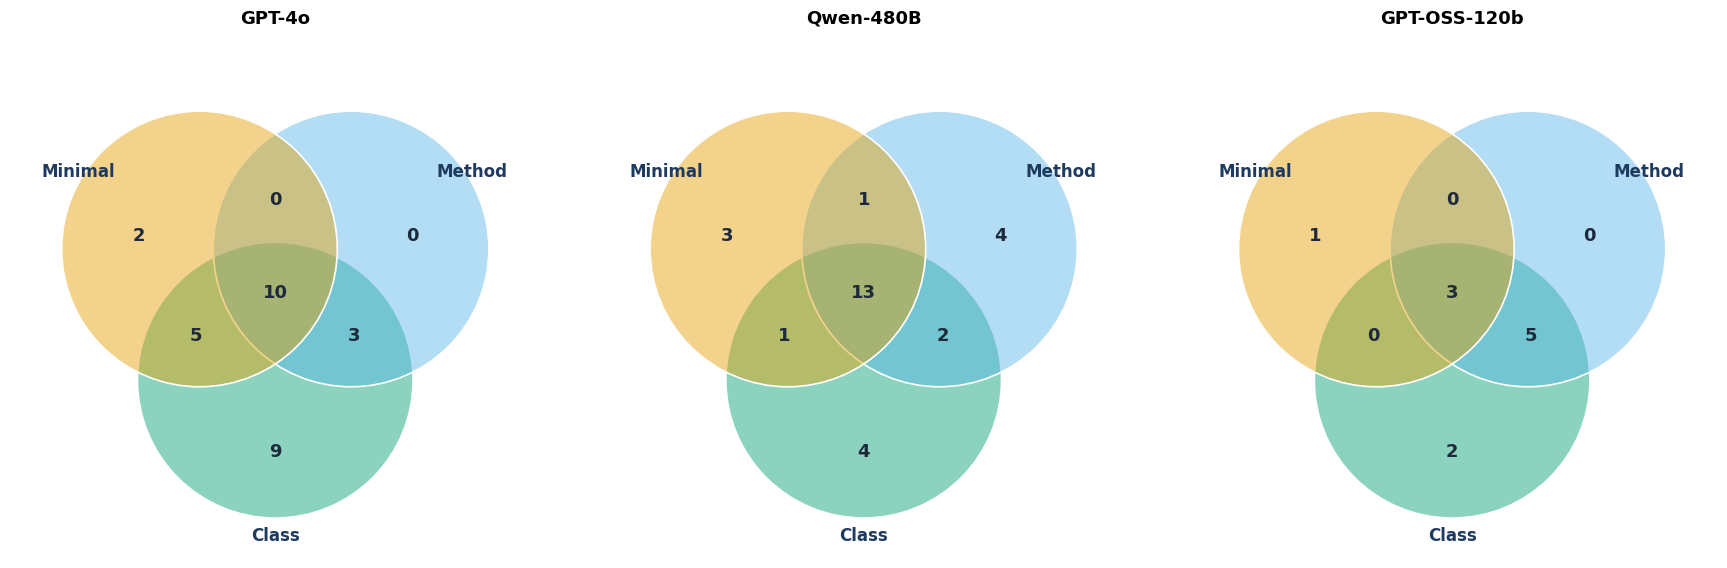

In [4]:
"""
venn_context_detection.py
==========================
Generates one 3-way Venn diagram per model showing which instances
are detected by Minimal, Method, and/or Class context variants.
Uses perfectly equal fixed-size circles with actual counts as labels.
No matplotlib-venn needed.
"""

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DETECTED_CSV = "/Volumes/Rachna-HD/RQResultsForPaper/RQ3/detected_bc_errortype_coverage.csv"
BUMP_CSV     = "/Volumes/Rachna-HD/ConfigFiles/Candidate_BUMP_Instance_errorTypes_with_categories.csv"
OUTPUT_DIR   = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures"

MODEL_ORDER   = ['GPT-4o', 'Qwen-480B', 'GPT-OSS-120b']
VARIANT_ORDER = ['Minimal', 'Method', 'Class']

# Wong colorblind-safe palette
COLORS = {
    'Minimal': '#E69F00',  # orange
    'Method':  '#56B4E9',  # sky blue
    'Class':   '#009E73',  # bluish green
}
# ──────────────────────────────────────────────────────────────────────────────

# ── Geometry: perfectly equal circles ────────────────────────────────────────
RADIUS = 0.40
OFFSET = 0.22

CENTERS = {
    'Minimal': (-OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Method':  (+OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Class':   ( 0.0,    -OFFSET / math.cos(math.radians(30))),
}

_s = OFFSET * 0.95
REGION_POS = {
    '100': (-_s * 1.9,  _s * 0.8),   # Minimal only
    '010': (+_s * 1.9,  _s * 0.8),   # Method only
    '001': ( 0.0,      -_s * 2.2),   # Class only
    '110': ( 0.0,       _s * 1.3),   # Minimal & Method
    '101': (-_s * 1.1, -_s * 0.6),  # Minimal & Class
    '011': (+_s * 1.1, -_s * 0.6),  # Method & Class
    '111': ( 0.0,       0.0),        # All three
}

SET_LABEL_POS = {
    'Minimal': (-OFFSET * 2.6,  OFFSET * 1.6),
    'Method':  (+OFFSET * 2.6,  OFFSET * 1.6),
    'Class':   ( 0.0,          -OFFSET * 3.2),
}
# ─────────────────────────────────────────────────────────────────────────────


def load_data(detected_csv, bump_csv):
    df = pd.read_csv(detected_csv, sep=None, engine='python',
                     dtype=str, keep_default_na=False)
    df['custom_id']       = df['custom_id'].str.strip()
    df['model']           = df['model'].str.strip()
    df['context_variant'] = df['context_variant'].str.strip()

    bump_df = pd.read_csv(bump_csv, sep=None, engine='python',
                          dtype=str, keep_default_na=False)
    all_ids = set(bump_df['custom_id'].str.strip().unique())
    return df, all_ids


def get_detected_sets(df, model):
    mdf = df[df['model'] == model]
    return {v: set(mdf[mdf['context_variant'] == v]['custom_id'].unique())
            for v in VARIANT_ORDER}


def plot_venn(model, sets, all_ids, ax):
    A, B, C = sets['Minimal'], sets['Method'], sets['Class']

    only_A  = A - B - C
    only_B  = B - A - C
    only_C  = C - A - B
    AB_only = (A & B) - C
    AC_only = (A & C) - B
    BC_only = (B & C) - A
    ABC     = A & B & C
    none    = all_ids - A - B - C

    region_counts = {
        '100': len(only_A),
        '010': len(only_B),
        '001': len(only_C),
        '110': len(AB_only),
        '101': len(AC_only),
        '011': len(BC_only),
        '111': len(ABC),
    }

    # ── Draw filled circles (back → front) ───────────────────────────────
    for variant in ['Class', 'Method', 'Minimal']:
        cx, cy = CENTERS[variant]
        ax.add_patch(mpatches.Circle(
            (cx, cy), RADIUS,
            facecolor=to_rgba(COLORS[variant], alpha=0.45),
            edgecolor='white',
            linewidth=1.2,
            zorder=2,
        ))

    # ── Region count labels ───────────────────────────────────────────────
    for rid, (rx, ry) in REGION_POS.items():
        ax.text(rx, ry, str(region_counts[rid]),
                ha='center', va='center',
                fontsize=13, fontweight='bold', color='#1e293b',
                zorder=3)

    # ── Set name labels ───────────────────────────────────────────────────
    for variant, (lx, ly) in SET_LABEL_POS.items():
        ax.text(lx, ly, variant,
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='#1e3a5f',
                zorder=3)

    ax.set_title(model, fontsize=13, fontweight='bold', pad=2)

    lim = RADIUS + OFFSET + 0.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    # Console breakdown
    print(f"\n{model}:")
    print(f"  Minimal only        : {len(only_A)}")
    print(f"  Method only         : {len(only_B)}")
    print(f"  Class only          : {len(only_C)}")
    print(f"  Minimal & Method    : {len(AB_only)}")
    print(f"  Minimal & Class     : {len(AC_only)}")
    print(f"  Method  & Class     : {len(BC_only)}")
    print(f"  All three           : {len(ABC)}")
    print(f"  None                : {len(none)}")
    print(f"  Total BUMP          : {len(all_ids)}")


def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_ids = load_data(DETECTED_CSV, BUMP_CSV)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, model in zip(axes, MODEL_ORDER):
        sets = get_detected_sets(df, model)
        plot_venn(model, sets, all_ids, ax)

    plt.tight_layout(pad=2.5)

    out_pdf = out_dir / "venn_context_detection.pdf"
    out_png = out_dir / "venn_context_detection.png"
    fig.savefig(out_pdf, bbox_inches='tight', dpi=300)
    fig.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f"\nSaved → {out_pdf}")
    print(f"Saved → {out_png}")
    plt.show()


if __name__ == "__main__":
    main()


GPT-4o:
  Minimal only        : 2
  Method only         : 0
  Class only          : 9
  Minimal & Method    : 0
  Minimal & Class     : 5
  Method  & Class     : 3
  All three           : 10
  None                : 60
  Total BUMP          : 89

Qwen-480B:
  Minimal only        : 3
  Method only         : 4
  Class only          : 4
  Minimal & Method    : 1
  Minimal & Class     : 1
  Method  & Class     : 2
  All three           : 13
  None                : 61
  Total BUMP          : 89

GPT-OSS-120b:
  Minimal only        : 1
  Method only         : 0
  Class only          : 2
  Minimal & Method    : 0
  Minimal & Class     : 0
  Method  & Class     : 5
  All three           : 3
  None                : 78
  Total BUMP          : 89

Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.pdf
Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.png


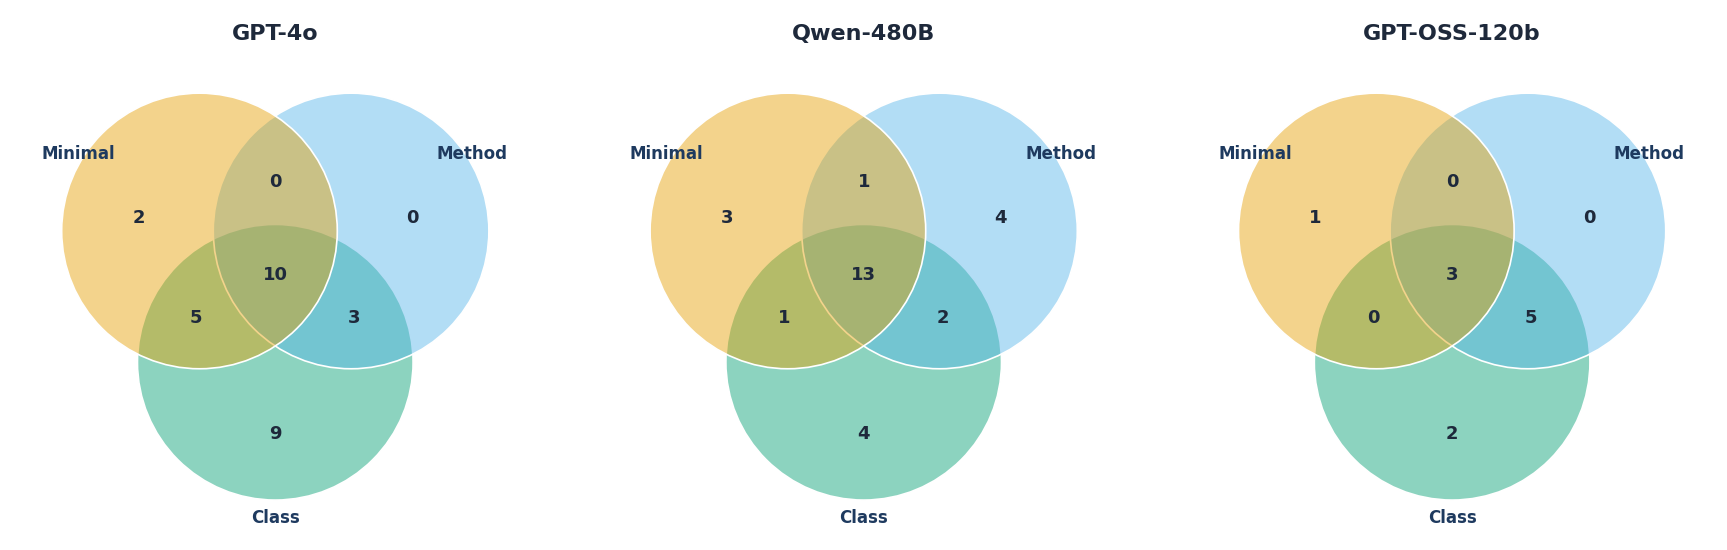

In [8]:
"""
venn_context_detection.py
==========================
Generates one 3-way Venn diagram per model showing which instances
are detected by Minimal, Method, and/or Class context variants.
Uses perfectly equal fixed-size circles with actual counts as labels.
No matplotlib-venn needed.
"""

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DETECTED_CSV = "/Volumes/Rachna-HD/RQResultsForPaper/RQ3/detected_bc_errortype_coverage.csv"
BUMP_CSV     = "/Volumes/Rachna-HD/ConfigFiles/Candidate_BUMP_Instance_errorTypes_with_categories.csv"
OUTPUT_DIR   = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures"

MODEL_ORDER   = ['GPT-4o', 'Qwen-480B', 'GPT-OSS-120b']
VARIANT_ORDER = ['Minimal', 'Method', 'Class']

# Wong colorblind-safe palette
COLORS = {
    'Minimal': '#E69F00',
    'Method':  '#56B4E9',
    'Class':   '#009E73',
}
# ──────────────────────────────────────────────────────────────────────────────

# ── Geometry ──────────────────────────────────────────────────────────────────
RADIUS = 0.40
OFFSET = 0.22

CENTERS = {
    'Minimal': (-OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Method':  (+OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Class':   ( 0.0,    -OFFSET / math.cos(math.radians(30))),
}

_s = OFFSET * 0.95
REGION_POS = {
    '100': (-_s * 1.9,  _s * 0.8),
    '010': (+_s * 1.9,  _s * 0.8),
    '001': ( 0.0,      -_s * 2.2),
    '110': ( 0.0,       _s * 1.3),
    '101': (-_s * 1.1, -_s * 0.6),
    '011': (+_s * 1.1, -_s * 0.6),
    '111': ( 0.0,       0.0),
}

SET_LABEL_POS = {
    'Minimal': (-OFFSET * 2.6,  OFFSET * 1.6),
    'Method':  (+OFFSET * 2.6,  OFFSET * 1.6),
    'Class':   ( 0.0,          -OFFSET * 3.2),
}
# ─────────────────────────────────────────────────────────────────────────────


def load_data(detected_csv, bump_csv):
    df = pd.read_csv(detected_csv, sep=None, engine='python',
                     dtype=str, keep_default_na=False)
    df['custom_id']       = df['custom_id'].str.strip()
    df['model']           = df['model'].str.strip()
    df['context_variant'] = df['context_variant'].str.strip()

    bump_df = pd.read_csv(bump_csv, sep=None, engine='python',
                          dtype=str, keep_default_na=False)
    all_ids = set(bump_df['custom_id'].str.strip().unique())
    return df, all_ids


def get_detected_sets(df, model):
    mdf = df[df['model'] == model]
    return {v: set(mdf[mdf['context_variant'] == v]['custom_id'].unique())
            for v in VARIANT_ORDER}


def plot_venn(model, sets, all_ids, ax):
    A, B, C = sets['Minimal'], sets['Method'], sets['Class']

    only_A  = A - B - C
    only_B  = B - A - C
    only_C  = C - A - B
    AB_only = (A & B) - C
    AC_only = (A & C) - B
    BC_only = (B & C) - A
    ABC     = A & B & C
    none    = all_ids - A - B - C

    region_counts = {
        '100': len(only_A),
        '010': len(only_B),
        '001': len(only_C),
        '110': len(AB_only),
        '101': len(AC_only),
        '011': len(BC_only),
        '111': len(ABC),
    }

    # ── Draw filled circles (back → front) ───────────────────────────────
    for variant in ['Class', 'Method', 'Minimal']:
        cx, cy = CENTERS[variant]
        ax.add_patch(mpatches.Circle(
            (cx, cy), RADIUS,
            facecolor=to_rgba(COLORS[variant], alpha=0.45),
            edgecolor='white',
            linewidth=1.2,
            zorder=2,
        ))

    # ── Region count labels ───────────────────────────────────────────────
    for rid, (rx, ry) in REGION_POS.items():
        ax.text(rx, ry, str(region_counts[rid]),
                ha='center', va='center',
                fontsize=13, fontweight='bold', color='#1e293b',
                zorder=3)

    # ── Set name labels ───────────────────────────────────────────────────
    for variant, (lx, ly) in SET_LABEL_POS.items():
        ax.text(lx, ly, variant,
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='#1e3a5f',
                zorder=3)

    # ── Axes limits (must be set before ax.text using lim) ───────────────
    lim = RADIUS + OFFSET + 0.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Model name inside top of axes ────────────────────────────────────
    ax.text(0, lim - 0.04, model,
            ha='center', va='top',
            fontsize=16, fontweight='bold', color='#1e293b',
            zorder=4)

    # Console breakdown
    print(f"\n{model}:")
    print(f"  Minimal only        : {len(only_A)}")
    print(f"  Method only         : {len(only_B)}")
    print(f"  Class only          : {len(only_C)}")
    print(f"  Minimal & Method    : {len(AB_only)}")
    print(f"  Minimal & Class     : {len(AC_only)}")
    print(f"  Method  & Class     : {len(BC_only)}")
    print(f"  All three           : {len(ABC)}")
    print(f"  None                : {len(none)}")
    print(f"  Total BUMP          : {len(all_ids)}")


def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_ids = load_data(DETECTED_CSV, BUMP_CSV)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, model in zip(axes, MODEL_ORDER):
        sets = get_detected_sets(df, model)
        plot_venn(model, sets, all_ids, ax)

    plt.tight_layout(pad=2.5)

    out_pdf = out_dir / "venn_context_detection.pdf"
    out_png = out_dir / "venn_context_detection.png"
    fig.savefig(out_pdf, bbox_inches='tight', dpi=300)
    fig.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f"\nSaved → {out_pdf}")
    print(f"Saved → {out_png}")
    plt.show()


if __name__ == "__main__":
    main()